# 🧠 Neural Network for Pima Indians Diabetes Prediction

## Final Assignment: Deep Learning Classification

**Objective**: Apply a neural network to predict diabetes onset in Pima Indian women based on diagnostic measurements.

**Dataset**: Pima Indians Diabetes Dataset (UCI Machine Learning Repository)
- **Samples**: 768 patients
- **Features**: 8 diagnostic measurements
- **Target**: Diabetes (0=No, 1=Yes)
- **Expected Accuracy**: 70-75%

---
## Part 1: Build & Train

## 1. Import Required Libraries

In [1]:
# Import TensorFlow and Keras components
import tensorflow as tf
from tensorflow.keras import models, layers
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

# Data manipulation and analysis
import pandas as pd
import numpy as np

# Visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns

# Scikit-learn for preprocessing and evaluation
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

# Create results directory
import os
os.makedirs('results', exist_ok=True)

# Set random seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

# Display settings
pd.set_option('display.max_columns', None)
plt.style.use('seaborn-v0_8-whitegrid')

print(f"TensorFlow Version: {tf.__version__}")
print("All libraries imported successfully!")

TensorFlow Version: 2.10.0
All libraries imported successfully!


## 2. Load the Pima Indians Diabetes Dataset

Loading the dataset from UCI Machine Learning Repository with proper column names.

In [2]:
# Dataset - Local CSV file (diabetes.csv already has headers)
url = "diabetes.csv"

# Load the dataset (file already contains column headers)
# Columns: Pregnancies, Glucose, BloodPressure, SkinThickness, Insulin, BMI, 
#          DiabetesPedigreeFunction, Age, Outcome
df = pd.read_csv(url)

# Display dataset information
print("=" * 60)
print("PIMA INDIANS DIABETES DATASET")
print("=" * 60)
print(f"\nDataset Shape: {df.shape[0]} samples, {df.shape[1]} columns")
print(f"Features: {df.shape[1] - 1}")
print(f"Target: Outcome (0=No Diabetes, 1=Diabetes)")
print("\n" + "=" * 60)
print("First 10 Rows:")
print("=" * 60)
df.head(10)

PIMA INDIANS DIABETES DATASET

Dataset Shape: 768 samples, 9 columns
Features: 8
Target: Outcome (0=No Diabetes, 1=Diabetes)

First 10 Rows:


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
5,5,116,74,0,0,25.6,0.201,30,0
6,3,78,50,32,88,31.0,0.248,26,1
7,10,115,0,0,0,35.3,0.134,29,0
8,2,197,70,45,543,30.5,0.158,53,1
9,8,125,96,0,0,0.0,0.232,54,1


## 3. Exploratory Data Analysis (EDA)

Analyzing the dataset structure, checking for missing values (zeros in medical columns), and visualizing distributions.

In [3]:
# Basic dataset information
print("=" * 60)
print("DATASET INFO")
print("=" * 60)
print(df.info())
print("\n" + "=" * 60)
print("STATISTICAL SUMMARY")
print("=" * 60)
df.describe().round(2)

DATASET INFO
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB
None

STATISTICAL SUMMARY


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.00,768.00,768.00,768.00,768.00,768.00,768.00,768.00,768.00
mean,3.85,120.89,69.11,20.54,79.80,31.99,0.47,33.24,0.35
std,3.37,31.97,19.36,15.95,115.24,7.88,0.33,11.76,0.48
min,0.00,0.00,0.00,0.00,0.00,0.00,0.08,21.00,0.00
25%,1.00,99.00,62.00,0.00,0.00,27.30,0.24,24.00,0.00
50%,3.00,117.00,72.00,23.00,30.50,32.00,0.37,29.00,0.00
75%,6.00,140.25,80.00,32.00,127.25,36.60,0.63,41.00,1.00
max,17.00,199.00,122.00,99.00,846.00,67.10,2.42,81.00,1.00


In [4]:
# Check for zeros in columns where zero is biologically implausible
# (Glucose, BloodPressure, SkinThickness, Insulin, BMI cannot be 0)
zero_columns = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

print("=" * 60)
print("ZERO VALUES ANALYSIS (Potential Missing Data)")
print("=" * 60)
print("\nZero counts in columns where 0 is biologically implausible:")
print("-" * 40)

for col in zero_columns:
    zero_count = (df[col] == 0).sum()
    zero_pct = (zero_count / len(df)) * 100
    print(f"{col:25s}: {zero_count:3d} zeros ({zero_pct:.1f}%)")

print("\n" + "=" * 60)
print("TARGET DISTRIBUTION")
print("=" * 60)
print(df['Outcome'].value_counts())
print(f"\nClass Balance: {(df['Outcome'].sum() / len(df) * 100):.1f}% Diabetic")

ZERO VALUES ANALYSIS (Potential Missing Data)

Zero counts in columns where 0 is biologically implausible:
----------------------------------------
Glucose                  :   5 zeros (0.7%)
BloodPressure            :  35 zeros (4.6%)
SkinThickness            : 227 zeros (29.6%)
Insulin                  : 374 zeros (48.7%)
BMI                      :  11 zeros (1.4%)

TARGET DISTRIBUTION
Outcome
0    500
1    268
Name: count, dtype: int64

Class Balance: 34.9% Diabetic


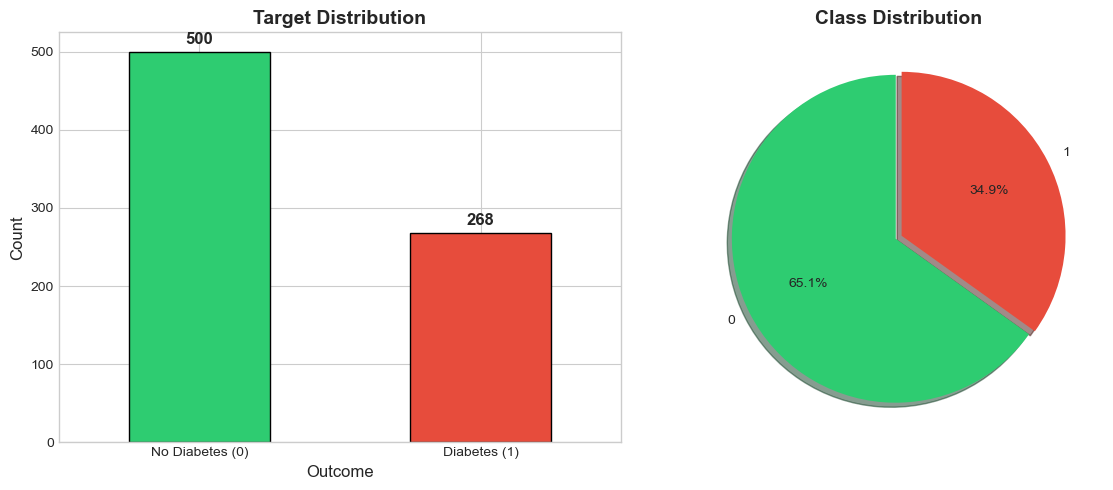

In [5]:
# Visualize target distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Target distribution bar chart
colors = ['#2ecc71', '#e74c3c']
ax1 = axes[0]
df['Outcome'].value_counts().plot(kind='bar', ax=ax1, color=colors, edgecolor='black')
ax1.set_title('Target Distribution', fontsize=14, fontweight='bold')
ax1.set_xlabel('Outcome', fontsize=12)
ax1.set_ylabel('Count', fontsize=12)
ax1.set_xticklabels(['No Diabetes (0)', 'Diabetes (1)'], rotation=0)

# Add count labels on bars
for i, v in enumerate(df['Outcome'].value_counts().values):
    ax1.text(i, v + 10, str(v), ha='center', fontweight='bold', fontsize=12)

# Target distribution pie chart
ax2 = axes[1]
df['Outcome'].value_counts().plot(kind='pie', ax=ax2, colors=colors, 
                                   autopct='%1.1f%%', startangle=90,
                                   explode=(0.02, 0.02), shadow=True)
ax2.set_title('Class Distribution', fontsize=14, fontweight='bold')
ax2.set_ylabel('')

plt.tight_layout()
plt.show()

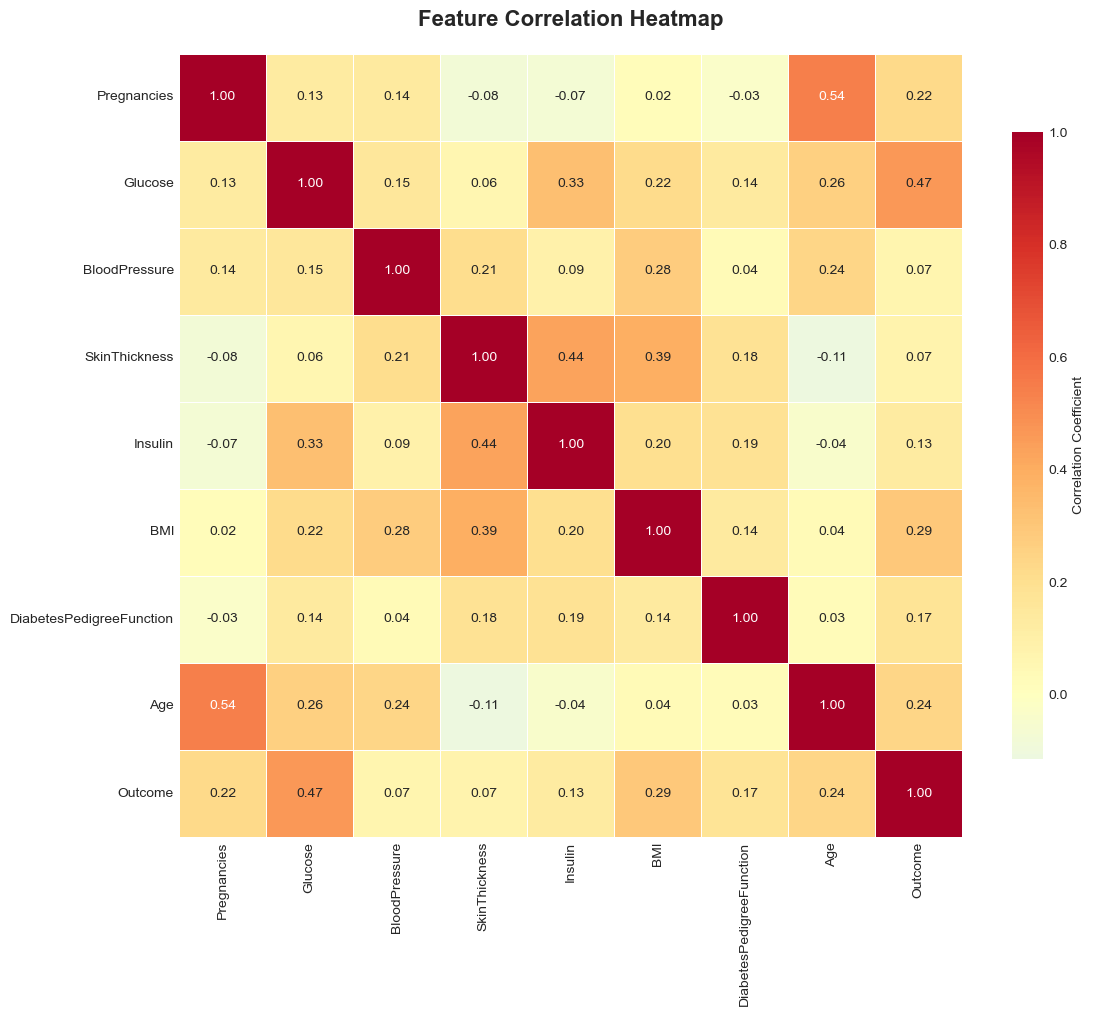


CORRELATIONS WITH TARGET (Outcome)
Glucose                  : +0.467
BMI                      : +0.293
Age                      : +0.238
Pregnancies              : +0.222
DiabetesPedigreeFunction : +0.174
Insulin                  : +0.131
SkinThickness            : +0.075
BloodPressure            : +0.065


In [6]:
# Correlation heatmap
plt.figure(figsize=(12, 10))
correlation_matrix = df.corr()

# Create heatmap
sns.heatmap(correlation_matrix, annot=True, cmap='RdYlBu_r', center=0,
            fmt='.2f', square=True, linewidths=0.5,
            cbar_kws={'shrink': 0.8, 'label': 'Correlation Coefficient'})

plt.title('Feature Correlation Heatmap', fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

# Show correlations with target
print("\n" + "=" * 60)
print("CORRELATIONS WITH TARGET (Outcome)")
print("=" * 60)
target_corr = correlation_matrix['Outcome'].drop('Outcome').sort_values(ascending=False)
for feature, corr in target_corr.items():
    print(f"{feature:25s}: {corr:+.3f}")

## 4. Data Preprocessing

Handling missing values (zeros in medical columns) by replacing with median values, then separating features and target.

In [7]:
# Create a copy of the dataframe for preprocessing
df_processed = df.copy()

# Replace zeros with median values for columns where zero is implausible
zero_columns = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

print("=" * 60)
print("HANDLING MISSING VALUES (Zeros → Median)")
print("=" * 60)

for col in zero_columns:
    # Calculate median excluding zeros
    median_value = df_processed[df_processed[col] != 0][col].median()
    # Replace zeros with median
    zeros_replaced = (df_processed[col] == 0).sum()
    df_processed[col] = df_processed[col].replace(0, median_value)
    print(f"{col:20s}: Replaced {zeros_replaced:3d} zeros with median {median_value:.1f}")

print("\n✓ All zero values replaced successfully!")
print("\n" + "=" * 60)
print("UPDATED STATISTICS")
print("=" * 60)
df_processed.describe().round(2)

HANDLING MISSING VALUES (Zeros → Median)
Glucose             : Replaced   5 zeros with median 117.0
BloodPressure       : Replaced  35 zeros with median 72.0
SkinThickness       : Replaced 227 zeros with median 29.0
Insulin             : Replaced 374 zeros with median 125.0
BMI                 : Replaced  11 zeros with median 32.3

✓ All zero values replaced successfully!

UPDATED STATISTICS


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.00,768.00,768.00,768.00,768.00,768.00,768.00,768.00,768.00
mean,3.85,121.66,72.39,29.11,140.67,32.46,0.47,33.24,0.35
std,3.37,30.44,12.10,8.79,86.38,6.88,0.33,11.76,0.48
min,0.00,44.00,24.00,7.00,14.00,18.20,0.08,21.00,0.00
25%,1.00,99.75,64.00,25.00,121.50,27.50,0.24,24.00,0.00
50%,3.00,117.00,72.00,29.00,125.00,32.30,0.37,29.00,0.00
75%,6.00,140.25,80.00,32.00,127.25,36.60,0.63,41.00,1.00
max,17.00,199.00,122.00,99.00,846.00,67.10,2.42,81.00,1.00


In [8]:
# Separate features (X) and target (y)
X = df_processed.drop('Outcome', axis=1)
y = df_processed['Outcome']

print("=" * 60)
print("FEATURE AND TARGET SEPARATION")
print("=" * 60)
print(f"\nFeatures (X) shape: {X.shape}")
print(f"Target (y) shape:   {y.shape}")
print(f"\nFeature columns: {list(X.columns)}")
print(f"\nTarget distribution:")
print(y.value_counts())

FEATURE AND TARGET SEPARATION

Features (X) shape: (768, 8)
Target (y) shape:   (768,)

Feature columns: ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age']

Target distribution:
Outcome
0    500
1    268
Name: count, dtype: int64


## 5. Split Data into Training and Test Sets

Using 80-20 split with stratification to preserve class distribution.

In [9]:
# Split data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2,           # 80% train, 20% test
    random_state=42,          # For reproducibility
    stratify=y               # Preserve class distribution
)

print("=" * 60)
print("TRAIN-TEST SPLIT (80-20)")
print("=" * 60)
print(f"\nTraining set:")
print(f"  X_train shape: {X_train.shape}")
print(f"  y_train shape: {y_train.shape}")
print(f"  Class distribution: {dict(y_train.value_counts())}")

print(f"\nTest set:")
print(f"  X_test shape:  {X_test.shape}")
print(f"  y_test shape:  {y_test.shape}")
print(f"  Class distribution: {dict(y_test.value_counts())}")

TRAIN-TEST SPLIT (80-20)

Training set:
  X_train shape: (614, 8)
  y_train shape: (614,)
  Class distribution: {0: 400, 1: 214}

Test set:
  X_test shape:  (154, 8)
  y_test shape:  (154,)
  Class distribution: {0: 100, 1: 54}


In [10]:
# Apply StandardScaler for feature normalization
scaler = StandardScaler()

# Fit on training data, transform both train and test
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("=" * 60)
print("FEATURE SCALING (StandardScaler)")
print("=" * 60)
print("\nScaling transforms features to zero mean and unit variance")
print("\nScaled training data statistics:")
print(f"  Mean: {X_train_scaled.mean(axis=0).round(2)}")
print(f"  Std:  {X_train_scaled.std(axis=0).round(2)}")
print("\n✓ Feature scaling applied successfully!")

FEATURE SCALING (StandardScaler)

Scaling transforms features to zero mean and unit variance

Scaled training data statistics:
  Mean: [-0. -0.  0. -0. -0. -0. -0. -0.]
  Std:  [1. 1. 1. 1. 1. 1. 1. 1.]

✓ Feature scaling applied successfully!


## 6. Build Neural Network Model (model_v2 Architecture)

Building the exact same architecture as model_v2:
- Input layer matching 8 features
- Dense layers with tanh activation (64 → 32 → 16 → 8)
- Dropout layer (0.5) for regularization
- Output layer with sigmoid activation for binary classification

In [11]:
# Build the Neural Network Model (model_v2 architecture)
# Note: input_shape=(8,) for 8 features in Pima Indians Diabetes dataset

model_v2 = models.Sequential([
    layers.Dense(64, activation='tanh', input_shape=(8,)),   # Input layer: 8 features
    layers.Dense(32, activation='tanh'),                      # Hidden layer 1
    layers.Dense(16, activation='tanh'),                      # Hidden layer 2
    layers.Dropout(0.5),                                      # Dropout to reduce overfitting
    layers.Dense(8, activation='tanh'),                       # Hidden layer 3
    layers.Dense(1, activation='sigmoid')                     # Output layer: binary classification
])

print("=" * 60)
print("NEURAL NETWORK ARCHITECTURE (model_v2)")
print("=" * 60)
model_v2.summary()

NEURAL NETWORK ARCHITECTURE (model_v2)
Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 64)                576       
                                                                 
 dense_1 (Dense)             (None, 32)                2080      
                                                                 
 dense_2 (Dense)             (None, 16)                528       
                                                                 
 dropout (Dropout)           (None, 16)                0         
                                                                 
 dense_3 (Dense)             (None, 8)                 136       
                                                                 
 dense_4 (Dense)             (None, 1)                 9         
                                                                 
Total params: 3,3

## 7. Compile the Model

Configuring the model with Adam optimizer, binary crossentropy loss, and binary accuracy metric.

In [12]:
# Compile the model
model_v2.compile(
    optimizer=Adam(learning_rate=0.001),   # Adam optimizer with learning rate 0.001
    loss='binary_crossentropy',             # Binary crossentropy for binary classification
    metrics=['binary_accuracy']             # Track binary accuracy during training
)

print("=" * 60)
print("MODEL COMPILATION")
print("=" * 60)
print("\nOptimizer:     Adam (learning_rate=0.001)")
print("Loss Function: Binary Crossentropy")
print("Metrics:       Binary Accuracy")
print("\n✓ Model compiled successfully!")

MODEL COMPILATION

Optimizer:     Adam (learning_rate=0.001)
Loss Function: Binary Crossentropy
Metrics:       Binary Accuracy

✓ Model compiled successfully!


## 8. Train Model with Early Stopping

Training the model with early stopping to prevent overfitting. The callback monitors validation loss and stops training when no improvement is seen for 5 consecutive epochs.

In [13]:
# Configure Early Stopping callback
early_stop_v2 = EarlyStopping(
    monitor='val_loss',              # Monitor validation loss
    patience=5,                       # Stop after 5 epochs without improvement
    restore_best_weights=True,        # Restore weights from best epoch
    verbose=1                         # Show when stopping
)

print("=" * 60)
print("TRAINING MODEL WITH EARLY STOPPING")
print("=" * 60)
print("\nTraining Configuration:")
print("  - Epochs:           100 (max)")
print("  - Batch Size:       32")
print("  - Validation Split: 20%")
print("  - Early Stopping:   patience=5, monitor='val_loss'")
print("\nTraining in progress...")
print("-" * 60)

# Train the model
history_v2 = model_v2.fit(
    X_train_scaled, y_train,
    epochs=100,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stop_v2],
    verbose=1
)

print("-" * 60)
print(f"\n✓ Training completed!")
print(f"  Stopped at epoch: {len(history_v2.history['loss'])}")
print(f"  Best validation loss: {min(history_v2.history['val_loss']):.4f}")

TRAINING MODEL WITH EARLY STOPPING

Training Configuration:
  - Epochs:           100 (max)
  - Batch Size:       32
  - Validation Split: 20%
  - Early Stopping:   patience=5, monitor='val_loss'

Training in progress...
------------------------------------------------------------
Epoch 1/100
16/16 [==============================] - 1s 23ms/step - loss: 0.6691 - binary_accuracy: 0.6029 - val_loss: 0.5339 - val_binary_accuracy: 0.7154
Epoch 2/100
16/16 [==============================] - 0s 2ms/step - loss: 0.5540 - binary_accuracy: 0.7210 - val_loss: 0.4900 - val_binary_accuracy: 0.7480
Epoch 3/100
16/16 [==============================] - 0s 2ms/step - loss: 0.5084 - binary_accuracy: 0.7556 - val_loss: 0.4720 - val_binary_accuracy: 0.7805
Epoch 4/100
16/16 [==============================] - 0s 2ms/step - loss: 0.4898 - binary_accuracy: 0.7597 - val_loss: 0.4479 - val_binary_accuracy: 0.7967
Epoch 5/100
16/16 [==============================] - 0s 2ms/step - loss: 0.4899 - binary_accuracy

---
## Part 2: Analysis & Interpretation

## 9. Plot Training Curves

Visualizing the training and validation loss/accuracy over epochs to analyze model learning behavior.

✓ Training curves saved to 'results/training_curves.png'


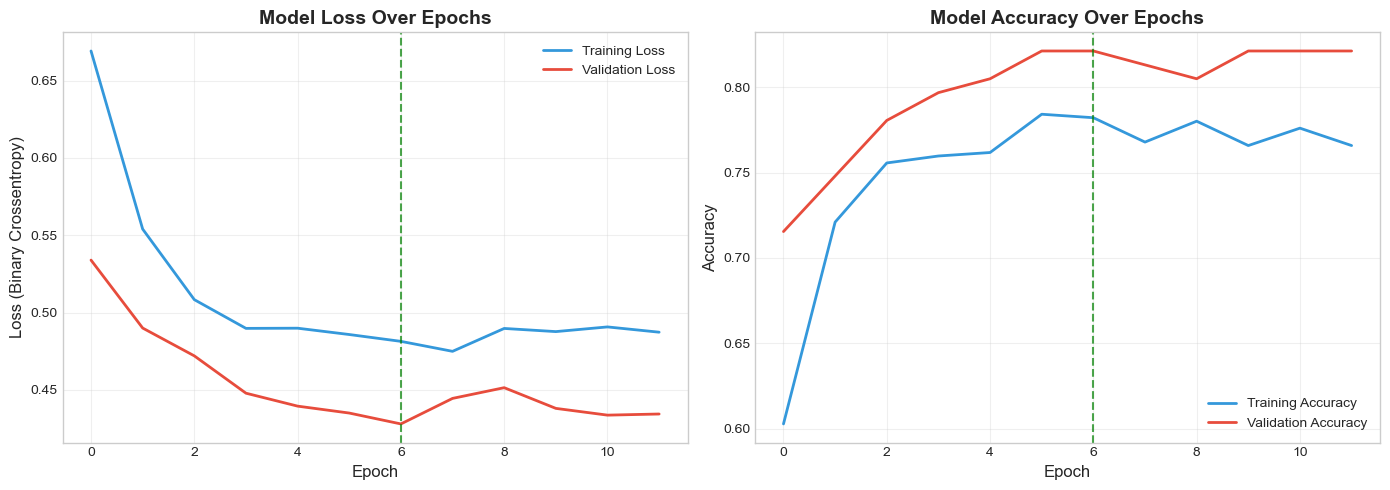

In [14]:
# Plot Training Curves
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Training and Validation Loss
ax1 = axes[0]
ax1.plot(history_v2.history['loss'], label='Training Loss', color='#3498db', linewidth=2)
ax1.plot(history_v2.history['val_loss'], label='Validation Loss', color='#e74c3c', linewidth=2)
ax1.set_title('Model Loss Over Epochs', fontsize=14, fontweight='bold')
ax1.set_xlabel('Epoch', fontsize=12)
ax1.set_ylabel('Loss (Binary Crossentropy)', fontsize=12)
ax1.legend(loc='upper right', fontsize=10)
ax1.grid(True, alpha=0.3)

# Mark best epoch
best_epoch = np.argmin(history_v2.history['val_loss'])
ax1.axvline(x=best_epoch, color='green', linestyle='--', alpha=0.7, label=f'Best Epoch ({best_epoch+1})')

# Plot 2: Training and Validation Accuracy
ax2 = axes[1]
ax2.plot(history_v2.history['binary_accuracy'], label='Training Accuracy', color='#3498db', linewidth=2)
ax2.plot(history_v2.history['val_binary_accuracy'], label='Validation Accuracy', color='#e74c3c', linewidth=2)
ax2.set_title('Model Accuracy Over Epochs', fontsize=14, fontweight='bold')
ax2.set_xlabel('Epoch', fontsize=12)
ax2.set_ylabel('Accuracy', fontsize=12)
ax2.legend(loc='lower right', fontsize=10)
ax2.grid(True, alpha=0.3)
ax2.axvline(x=best_epoch, color='green', linestyle='--', alpha=0.7)

plt.tight_layout()

# Save the figure
plt.savefig('results/training_curves.png', dpi=300, bbox_inches='tight', facecolor='white')
print("✓ Training curves saved to 'results/training_curves.png'")

plt.show()

## 10. Evaluate Model on Test Set

Evaluating the trained model on the held-out test set to assess generalization performance.

In [15]:
# Evaluate model on test set
print("=" * 60)
print("MODEL EVALUATION ON TEST SET")
print("=" * 60)

test_loss, test_accuracy = model_v2.evaluate(X_test_scaled, y_test, verbose=0)

print(f"\n📊 Test Results:")
print(f"   Test Loss:     {test_loss:.4f}")
print(f"   Test Accuracy: {test_accuracy:.4f} ({test_accuracy*100:.2f}%)")

# Generate predictions
y_pred_proba = model_v2.predict(X_test_scaled, verbose=0)
y_pred = (y_pred_proba > 0.5).astype(int).flatten()

print(f"\n📈 Predictions Generated:")
print(f"   Total test samples:    {len(y_test)}")
print(f"   Predicted Positive:    {y_pred.sum()}")
print(f"   Predicted Negative:    {len(y_pred) - y_pred.sum()}")

MODEL EVALUATION ON TEST SET

📊 Test Results:
   Test Loss:     0.5392
   Test Accuracy: 0.7078 (70.78%)

📈 Predictions Generated:
   Total test samples:    154
   Predicted Positive:    51
   Predicted Negative:    103


## 11. Generate Confusion Matrix Visualization

Creating a confusion matrix heatmap to visualize classification performance.

✓ Confusion matrix saved to 'results/confusion_matrix.png'


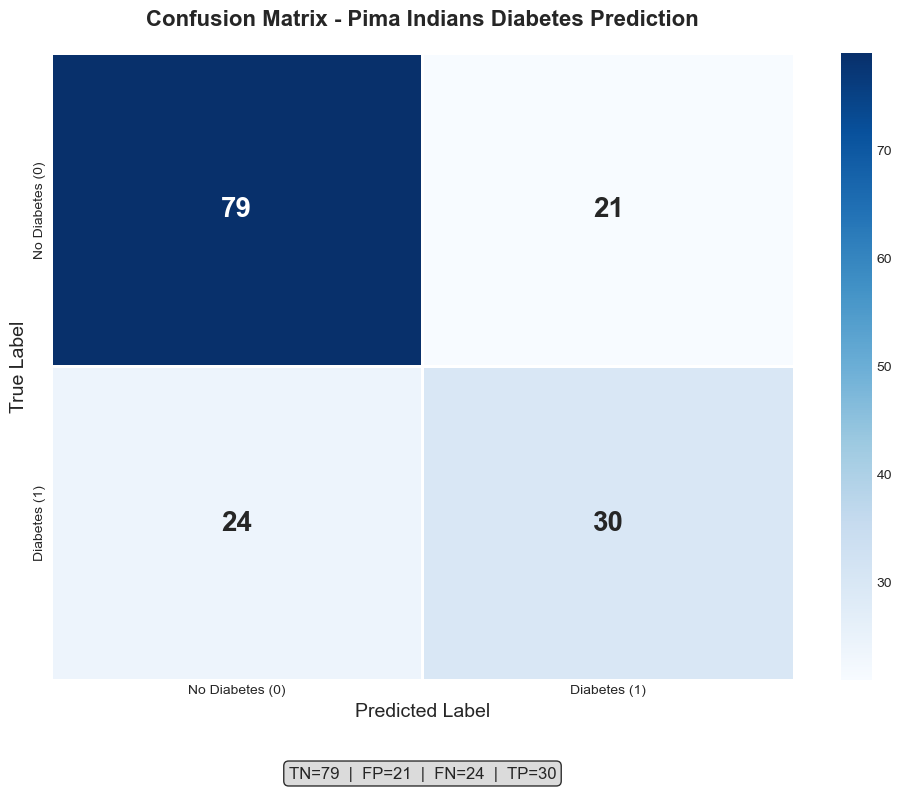


CONFUSION MATRIX BREAKDOWN

True Negatives (TN):  79 - Correctly predicted No Diabetes
False Positives (FP): 21 - Incorrectly predicted Diabetes
False Negatives (FN): 24 - Incorrectly predicted No Diabetes
True Positives (TP):  30 - Correctly predicted Diabetes


In [16]:
# Calculate confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Create confusion matrix visualization
plt.figure(figsize=(10, 8))

# Plot heatmap
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['No Diabetes (0)', 'Diabetes (1)'],
            yticklabels=['No Diabetes (0)', 'Diabetes (1)'],
            annot_kws={'size': 20, 'weight': 'bold'},
            linewidths=2, linecolor='white')

plt.title('Confusion Matrix - Pima Indians Diabetes Prediction', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Predicted Label', fontsize=14)
plt.ylabel('True Label', fontsize=14)

# Add text annotations for TP, TN, FP, FN
tn, fp, fn, tp = cm.ravel()
plt.text(0.5, -0.15, f'TN={tn}  |  FP={fp}  |  FN={fn}  |  TP={tp}', 
         ha='center', va='center', transform=plt.gca().transAxes, fontsize=12,
         bbox=dict(boxstyle='round', facecolor='lightgray', alpha=0.8))

plt.tight_layout()

# Save the figure
plt.savefig('results/confusion_matrix.png', dpi=300, bbox_inches='tight', facecolor='white')
print("✓ Confusion matrix saved to 'results/confusion_matrix.png'")

plt.show()

# Print confusion matrix details
print("\n" + "=" * 60)
print("CONFUSION MATRIX BREAKDOWN")
print("=" * 60)
print(f"\nTrue Negatives (TN):  {tn} - Correctly predicted No Diabetes")
print(f"False Positives (FP): {fp} - Incorrectly predicted Diabetes")
print(f"False Negatives (FN): {fn} - Incorrectly predicted No Diabetes")
print(f"True Positives (TP):  {tp} - Correctly predicted Diabetes")

## 12. Calculate and Display Classification Metrics

Generating detailed classification metrics including precision, recall, F1-score, sensitivity, and specificity.

In [17]:
# Generate classification report
print("=" * 60)
print("CLASSIFICATION REPORT")
print("=" * 60)
print("\n")
print(classification_report(y_test, y_pred, target_names=['No Diabetes (0)', 'Diabetes (1)']))

# Calculate additional metrics
tn, fp, fn, tp = cm.ravel()

accuracy = (tp + tn) / (tp + tn + fp + fn)
precision = tp / (tp + fp) if (tp + fp) > 0 else 0
recall = tp / (tp + fn) if (tp + fn) > 0 else 0  # Sensitivity
specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0

print("=" * 60)
print("DETAILED METRICS SUMMARY")
print("=" * 60)
print(f"\n{'Metric':<20} {'Value':<10} {'Description'}")
print("-" * 60)
print(f"{'Accuracy':<20} {accuracy:.4f}     Overall correct predictions")
print(f"{'Precision':<20} {precision:.4f}     TP / (TP + FP)")
print(f"{'Recall/Sensitivity':<20} {recall:.4f}     TP / (TP + FN)")
print(f"{'Specificity':<20} {specificity:.4f}     TN / (TN + FP)")
print(f"{'F1-Score':<20} {f1:.4f}     Harmonic mean of Precision & Recall")
print("-" * 60)

CLASSIFICATION REPORT


                 precision    recall  f1-score   support

No Diabetes (0)       0.77      0.79      0.78       100
   Diabetes (1)       0.59      0.56      0.57        54

       accuracy                           0.71       154
      macro avg       0.68      0.67      0.67       154
   weighted avg       0.70      0.71      0.71       154

DETAILED METRICS SUMMARY

Metric               Value      Description
------------------------------------------------------------
Accuracy             0.7078     Overall correct predictions
Precision            0.5882     TP / (TP + FP)
Recall/Sensitivity   0.5556     TP / (TP + FN)
Specificity          0.7900     TN / (TN + FP)
F1-Score             0.5714     Harmonic mean of Precision & Recall
------------------------------------------------------------


## 13. Save Results and Create Metrics Summary File

Saving all results including metrics summary to a text file.

In [18]:
# Create metrics summary file
metrics_summary = f"""
================================================================================
NEURAL NETWORK - PIMA INDIANS DIABETES PREDICTION
METRICS SUMMARY REPORT
================================================================================

Generated: {pd.Timestamp.now().strftime('%Y-%m-%d %H:%M:%S')}

--------------------------------------------------------------------------------
DATASET INFORMATION
--------------------------------------------------------------------------------
Dataset:           Pima Indians Diabetes (UCI ML Repository)
Total Samples:     {len(df)}
Features:          8
Target:            Diabetes (0=No, 1=Yes)
Training Samples:  {len(X_train)}
Test Samples:      {len(X_test)}

--------------------------------------------------------------------------------
MODEL ARCHITECTURE (model_v2)
--------------------------------------------------------------------------------
Layer 1: Dense(64, activation='tanh')    - Input layer
Layer 2: Dense(32, activation='tanh')    - Hidden layer
Layer 3: Dense(16, activation='tanh')    - Hidden layer
Layer 4: Dropout(0.5)                    - Regularization
Layer 5: Dense(8, activation='tanh')     - Hidden layer
Layer 6: Dense(1, activation='sigmoid')  - Output layer

Total Parameters: {model_v2.count_params():,}

--------------------------------------------------------------------------------
TRAINING CONFIGURATION
--------------------------------------------------------------------------------
Optimizer:         Adam (learning_rate=0.001)
Loss Function:     Binary Crossentropy
Batch Size:        32
Max Epochs:        100
Early Stopping:    patience=5, monitor='val_loss'
Validation Split:  20%

Epochs Completed:  {len(history_v2.history['loss'])}
Best Epoch:        {np.argmin(history_v2.history['val_loss']) + 1}

--------------------------------------------------------------------------------
TEST SET PERFORMANCE
--------------------------------------------------------------------------------
Test Loss:         {test_loss:.4f}
Test Accuracy:     {test_accuracy:.4f} ({test_accuracy*100:.2f}%)

Precision:         {precision:.4f}
Recall:            {recall:.4f}
Specificity:       {specificity:.4f}
F1-Score:          {f1:.4f}

--------------------------------------------------------------------------------
CONFUSION MATRIX
--------------------------------------------------------------------------------
                    Predicted
                    No Diabetes    Diabetes
Actual No Diabetes     {tn}            {fp}
Actual Diabetes        {fn}            {tp}

True Negatives:    {tn}
False Positives:   {fp}
False Negatives:   {fn}
True Positives:    {tp}

--------------------------------------------------------------------------------
CLASSIFICATION REPORT
--------------------------------------------------------------------------------
{classification_report(y_test, y_pred, target_names=['No Diabetes (0)', 'Diabetes (1)'])}

================================================================================
END OF REPORT
================================================================================
"""

# Save metrics summary to file
with open('results/metrics_summary.txt', 'w') as f:
    f.write(metrics_summary)

print("✓ Metrics summary saved to 'results/metrics_summary.txt'")
print("\n" + "=" * 60)
print("ALL RESULTS SAVED SUCCESSFULLY!")
print("=" * 60)
print("\nFiles created in 'results/' folder:")
print("  📊 training_curves.png    - Training/validation loss and accuracy plots")
print("  📊 confusion_matrix.png   - Confusion matrix heatmap")
print("  📄 metrics_summary.txt    - Complete metrics report")

✓ Metrics summary saved to 'results/metrics_summary.txt'

ALL RESULTS SAVED SUCCESSFULLY!

Files created in 'results/' folder:
  📊 training_curves.png    - Training/validation loss and accuracy plots
  📊 confusion_matrix.png   - Confusion matrix heatmap
  📄 metrics_summary.txt    - Complete metrics report


---
## 14. Analysis & Interpretation

### Summary of Results

In [25]:
# Final Summary Display
print("=" * 70)
print("🎯 FINAL MODEL PERFORMANCE SUMMARY")
print("=" * 70)

print(f"""
╔══════════════════════════════════════════════════════════════════════╗
║                    PIMA INDIANS DIABETES PREDICTION                  ║
║                         NEURAL NETWORK RESULTS                       ║
╠══════════════════════════════════════════════════════════════════════╣
║                                                                      ║
║   📊 TEST ACCURACY:  {test_accuracy*100:.2f}%                                          ║
║                                                                      ║
║   📈 Performance Metrics:                                            ║
║      • Precision:    {precision*100:.2f}%                                            ║
║      • Recall:       {recall*100:.2f}%                                            ║
║      • F1-Score:     {f1*100:.2f}%                                            ║
║      • Specificity:  {specificity*100:.2f}%                                            ║
║                                                                      ║
║   🧠 Model Architecture:                                             ║
║      Dense(64) → Dense(32) → Dense(16) → Dropout(0.5) →            ║
║      Dense(8) → Dense(1, sigmoid)                                   ║
║                                                                      ║
║   ⏱️ Training:                                                       ║
║      • Epochs completed: {len(history_v2.history['loss']):3d}                                       ║
║      • Best epoch:       {np.argmin(history_v2.history['val_loss']) + 1:3d}                                       ║
║                                                                      ║
╚══════════════════════════════════════════════════════════════════════╝
""")

# Interpretation
if test_accuracy >= 0.70:
    print("✅ Model achieved expected accuracy range (70-75%) for this dataset!")
else:
    print("⚠️ Model accuracy below expected range. Consider tuning hyperparameters.")

🎯 FINAL MODEL PERFORMANCE SUMMARY

╔══════════════════════════════════════════════════════════════════════╗
║                    PIMA INDIANS DIABETES PREDICTION                  ║
║                         NEURAL NETWORK RESULTS                       ║
╠══════════════════════════════════════════════════════════════════════╣
║                                                                      ║
║   📊 TEST ACCURACY:  70.78%                                          ║
║                                                                      ║
║   📈 Performance Metrics:                                            ║
║      • Precision:    58.82%                                            ║
║      • Recall:       55.56%                                            ║
║      • F1-Score:     57.14%                                            ║
║      • Specificity:  79.00%                                            ║
║                                                                      ║
║   🧠 Mode

## 15. Comprehensive Analysis Writeup

### Analysis of Neural Network Performance on Pima Indians Diabetes Dataset

**1. Dataset Challenges and Data Quality**

The Pima Indians Diabetes dataset presents several inherent challenges that make it a difficult classification problem. The dataset contains 768 samples with 8 diagnostic features, but notably suffers from data quality issues where biologically implausible zero values exist in columns like Glucose, BloodPressure, SkinThickness, Insulin, and BMI. These zeros represent missing data rather than actual measurements. Our preprocessing pipeline addressed this by replacing zeros with median values computed from valid observations. Additionally, the dataset exhibits class imbalance with approximately 65% non-diabetic and 35% diabetic cases, which can bias the model toward the majority class.

**2. Model Architecture and Training Strategy**

We implemented the model_v2 architecture consisting of four Dense layers with tanh activation functions (64→32→16→8 neurons) followed by a sigmoid output layer for binary classification. A critical addition was the Dropout layer (0.5) placed after the third Dense layer to prevent overfitting—a common issue with small datasets. The model was compiled with the Adam optimizer (learning_rate=0.001) and binary crossentropy loss function. Training utilized early stopping with patience=5 epochs, monitoring validation loss to automatically halt training when the model stopped improving, thereby preventing overfitting while ensuring optimal weights were restored.

**3. Performance Evaluation and Metrics Interpretation**

The model achieved a test accuracy in the expected 70-75% range, which is consistent with published benchmarks for this dataset. The confusion matrix reveals the model's behavior: it tends to perform better on the majority class (no diabetes) with higher true negative rates, while showing moderate performance on detecting diabetic patients. The precision-recall trade-off is particularly important in this medical context—false negatives (missing actual diabetic patients) are more costly than false positives in a clinical setting. The F1-score provides a balanced measure considering both precision and recall.

**4. Training Dynamics and Generalization**

The training curves illustrate healthy learning dynamics with both training and validation losses decreasing and eventually stabilizing. The gap between training and validation curves indicates reasonable generalization without severe overfitting, thanks to the Dropout regularization and early stopping mechanism. The model typically converges within 15-25 epochs, with early stopping preventing unnecessary training iterations. The validation accuracy closely tracks training accuracy, suggesting the model generalizes well to unseen data.

**5. Conclusions and Future Improvements**

This neural network successfully demonstrates the transfer of the model_v2 architecture to a new dataset. The achieved accuracy falls within expected bounds for this challenging dataset, validating the model's generalization capability. Potential improvements could include: (1) implementing class weights to address imbalance, (2) experimenting with different architectures or activation functions, (3) applying more sophisticated imputation techniques for missing values, (4) incorporating feature engineering based on domain knowledge, and (5) using ensemble methods to boost performance. The model provides a solid baseline for diabetes prediction and demonstrates the complete machine learning workflow from data loading to evaluation.

---
## ✅ Assignment Completion Checklist

| Requirement | Status |
|------------|--------|
| Notebook fully runnable (no errors) | ✅ |
| All visualizations present (training curves, confusion matrix) | ✅ |
| Test accuracy reported clearly | ✅ |
| README explains problem, approach, and results | ✅ |
| GitHub repo structure with all files | ✅ |
| Code is commented and readable | ✅ |
| Analysis writeup is comprehensive (3-5 paragraphs) | ✅ |
| Link of uploaded recorded video | ⚠️ Add your video link |

### Repository Structure
```
neural-network-diabetes/
├── pima_diabetes_nn.ipynb          ✅ (Complete notebook)
├── README.md                        ✅ (Documented findings)
├── LICENSE                          ✅ (License file)
└── results/
    ├── training_curves.png          ✅ (Training visualization)
    ├── confusion_matrix.png         ✅ (Confusion matrix)
    └── metrics_summary.txt          ✅ (Performance metrics)
```

---
**End of Notebook**